This is a simple notebook to use Logistic Regression model for the Ising model.  
It accompanies Chapter 5 of the book (4 of 5).  
Copyright: Viviana Acquaviva (2023); see also other data credits below.  
Modifications by Aaron Romanowsky.  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pickle
from matplotlib import cm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate, train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics

### First, let's take a look at those sigmoids!

In [5]:
x = np.linspace(-10,10,100)
z = -2*x + 5 #Linear bit

Let's say that the probability that something will happen is called $\pi$. 

The logistic model assumes that

$log (\frac{\pi}{1-\pi}$) = z 

We can now solve for $\pi$:

In [6]:
pi = 1/(1 + np.exp(-z))

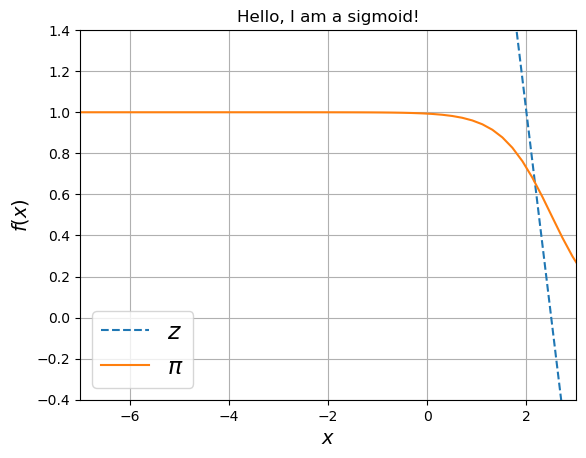

In [7]:
fig1 = plt.figure()
plt.plot(x, z, '--', label='$z$')
plt.plot(x, pi, '-', label='$\\pi$')
plt.xlim(-7,3)
plt.ylim(-0.05,1.05)
plt.ylim(-0.4,1.4)
plt.title('Hello, I am a sigmoid!')
plt.xlabel('$x$', fontsize=14)
plt.legend(loc='best',fontsize=17)
#plt.ylabel('$\pi$',fontsize=14)
plt.ylabel('$f(x)$',fontsize=14)
plt.grid()

Questions:
    
- Where is that $\pi$ = 0.5? 

- What happens if the slope of the linear model is negative?

### We can now see an example from Mehta et al 2018:

["A high-bias, low-variance introduction to Machine Learning for physicists"](https://arxiv.org/abs/1803.08823).

(Thank you to Pankaj Mehta and David Schwab)!

We are trying to use a logistic regression model to predict whether a material is in a ordered or disordered phase, based on its spin configuration. In an ordered phase, the spins are aligned. The representation is a 2D lattice so our features are the spin states of each element in the lattice. The physical model, known as Ising model, predicts that the transition depends on temperature and is smeared (for a finite-size lattice), around a critical temperature $T_c$.

The training data is composed of 160,000 Monte Carlo simulations in a range of temperatures, and their labels.

Possible applications of this formalism involve predicting the critical temperature for more complex systems.

Reading in the data might take a little while.

In [8]:
#This is gratefully borrowed with permission from the notebooks maintained by P. Mehta.

######### LOAD DATA
# The data consists of 16*10000 samples taken in T=np.arange(0.25,4.0001,0.25):
data_file_name = 'Ising2DFM_reSample_L40_T=All.pkl'
# The labels are obtained from the following file:
label_file_name = 'Ising2DFM_reSample_L40_T=All_labels.pkl'


#DATA
with open(data_file_name, 'rb') as pickle_file:
    data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits)

data = np.unpackbits(data).reshape(-1, 1600) # Decompress array and reshape for convenience
data=data.astype('int')
data[np.where(data==0)]=-1 # map 0 state to -1 (Ising variable can take values +/-1)

#LABELS (convention is 1 for ordered states and 0 for disordered states)
with open(label_file_name, 'rb') as pickle_file:
    labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)

In [9]:
data.shape

(160000, 1600)

In [10]:
np.unique(labels)

array([0, 1])

We can take a look at the label distribution:

Text(0, 0.5, 'State')

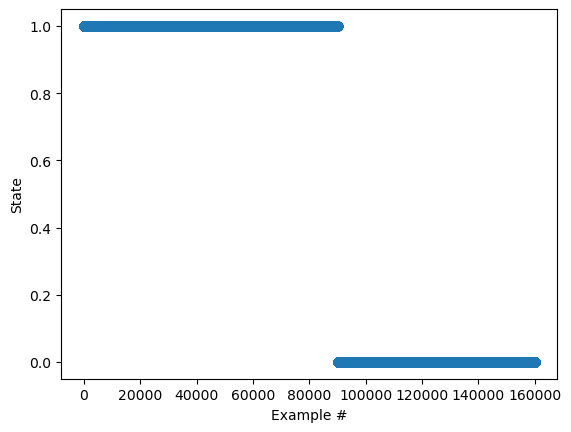

In [11]:
fig2 = plt.figure()
plt.scatter(np.arange(data.shape[0]),labels)
plt.xlabel('Example #')
plt.ylabel('State')
#labels: 1 = ordered or near-critical
#labels: 0 = disordered

Balanced or imbalanced?

In [12]:
len(np.where(labels == 1)[0])

90000

#### We can take a look at a few examples:

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
[ 1  1 -1 -1 -1 -1 -1 -1 -1 -1  1  1 -1  1  1 -1  1  1 -1 -1 -1 -1 -1 -1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]


<Figure size 1500x800 with 0 Axes>

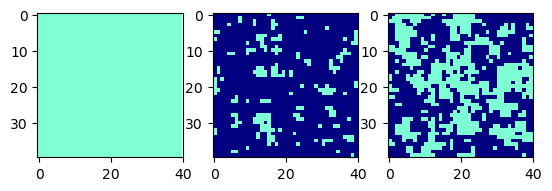

In [16]:
#H/T: https://stackoverflow.com/questions/16834861/create-own-colormap-using-matplotlib-and-plot-color-scale
cmap = matplotlib.colors.ListedColormap(["aquamarine","navy"], name='from_list', N=None)

fig3 = plt.figure(figsize=(15,8))
fig, axarr = plt.subplots(nrows=1, ncols=3)
axarr[0].imshow(data[0].reshape(40,40), cmap = cmap) #first object has label "1"
axarr[1].imshow(data[80000].reshape(40,40), cmap = cmap) #from documentation, this is critical-ish (between 60, and 90,000)
axarr[2].imshow(data[100000].reshape(40,40), cmap = cmap) #disordered
for i in range(3):
    axarr[i].set_xticks([0,20,40]);
print(data[0].reshape(40,40)[0]) # print first row
print(data[80000].reshape(40,40)[0]) # print first row
print(data[100000].reshape(40,40)[0]) # print first row

### Let's pick a random selection to speed up the computations.

In [17]:
np.random.seed(10)
sel = np.random.choice(data.shape[0], 16000, replace = False)
seldata = data[sel,:]
sellabels = labels[sel]

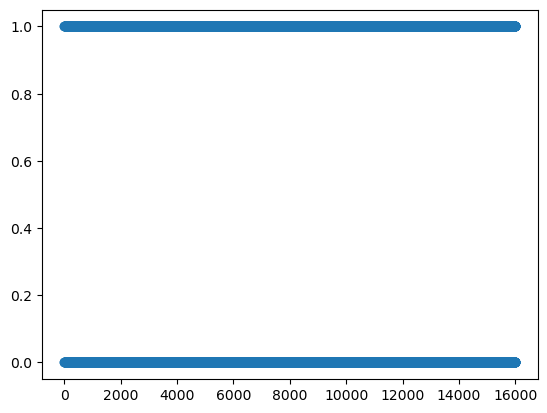

In [18]:
fig4 = plt.figure()
plt.scatter(np.arange(seldata.shape[0]),sellabels); #The random selection also has the advantage of reshuffling the data!

### And now time for the logistic regression model.

In [19]:
model = LogisticRegression(max_iter = 1000) #This uses a numerical method to find the minimum of the loss function
model.get_params() #Note that (unlike in linear regression) regularization is the norm!

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 1000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [20]:
model

LogisticRegression(max_iter=1000)

We can use cross validation, as usual:

In [21]:
#Takes 5-10 seconds
results = cross_validate(model, seldata, sellabels, 
                         cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score = True)
results 

{'fit_time': array([1.67034602, 1.814466  , 0.61912107, 1.86405706, 0.53684497]),
 'score_time': array([0.0086031 , 0.00666809, 0.00594401, 0.00560904, 0.00847721]),
 'test_score': array([0.68625  , 0.6725   , 0.666875 , 0.6678125, 0.6840625]),
 'train_score': array([0.77796875, 0.77335937, 0.77703125, 0.77710937, 0.77265625])}

### Note: which metric do you think those numbers represent?

The standard output of Logistic Regression is accuracy (a classification metric!)

This is sub-optimal because we also want to access the probabilities. We'll look at that in a moment.

### We can do our own grid search to optimize the regularization parameter C:

In [22]:
#Note that our data is already very regular (feature values are-1/1, so we are not doing any scaling).
for C in np.logspace(-3,3,7):
    model = LogisticRegression(max_iter=1000, C = C)
    results = cross_validate(model, seldata, sellabels, 
                         cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score = True)
    print('C/Average test accuracy for C = ', '{:.3e} {:s} {:.3f} {:s} {:.3f}'.format(C, 'is ', results['test_score'].mean(),'+-',results['test_score'].std()))
    print('C/Average train accuracy for C = ', '{:.3e} {:s} {:.3f} {:s} {:.3f}'.format(C, 'is ', results['train_score'].mean(),'+-',results['train_score'].std()))

C/Average test accuracy for C =  1.000e-03 is  0.666 +- 0.009
C/Average train accuracy for C =  1.000e-03 is  0.748 +- 0.003
C/Average test accuracy for C =  1.000e-02 is  0.674 +- 0.009
C/Average train accuracy for C =  1.000e-02 is  0.774 +- 0.002
C/Average test accuracy for C =  1.000e-01 is  0.676 +- 0.008
C/Average train accuracy for C =  1.000e-01 is  0.776 +- 0.002
C/Average test accuracy for C =  1.000e+00 is  0.676 +- 0.008
C/Average train accuracy for C =  1.000e+00 is  0.776 +- 0.002
C/Average test accuracy for C =  1.000e+01 is  0.675 +- 0.008
C/Average train accuracy for C =  1.000e+01 is  0.775 +- 0.002
C/Average test accuracy for C =  1.000e+02 is  0.675 +- 0.008
C/Average train accuracy for C =  1.000e+02 is  0.776 +- 0.002
C/Average test accuracy for C =  1.000e+03 is  0.675 +- 0.008
C/Average train accuracy for C =  1.000e+03 is  0.776 +- 0.002


### Questions:

- Which value of C should we pick?

- How is this model's performance?

### Here we generate labels in order to check predictions.

For those classifiers that are solving a regression problem under the hood, there is the handy "predict_proba" method.

In [23]:
model = LogisticRegression(C=1.0, max_iter=1000)

ypred = cross_val_predict(model, seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10))

ypred_prob = cross_val_predict(model, seldata, sellabels, \
                               cv = KFold(n_splits=5, shuffle=True, random_state=10), method = 'predict_proba')

The output of predict_proba gives the probability to belong to disordered (label 0) or ordered (label 1) phase. The simple classifier output is the class with p > 0.5. We can look at this to convince ourselves:

In [24]:
np.column_stack([ypred_prob, ypred]) # probability label = 0, probability label = 1, predicted label

array([[0.35123293, 0.64876707, 1.        ],
       [0.3290957 , 0.6709043 , 1.        ],
       [0.04824153, 0.95175847, 1.        ],
       ...,
       [0.50255847, 0.49744153, 0.        ],
       [0.37805753, 0.62194247, 1.        ],
       [0.33837455, 0.66162545, 1.        ]], shape=(16000, 3))

Text(0, 0.5, 'true label')

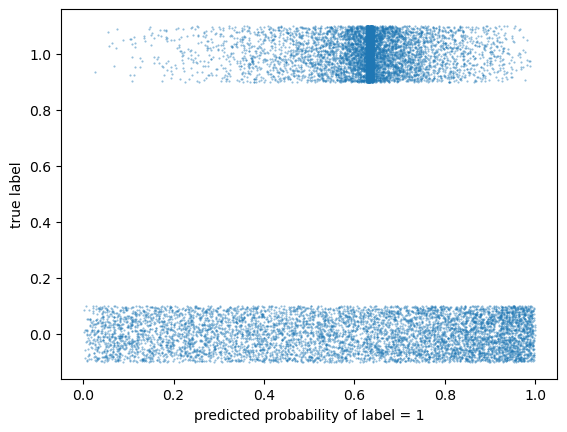

In [25]:
# add random scatter in y direction for visibility
fig5 = plt.figure()
plt.plot(ypred_prob[:,1],sellabels+0.2*np.random.uniform(size=len(sellabels))-0.1,'o',ms=0.5, alpha=0.5)
plt.xlabel('predicted probability of label = 1')
plt.ylabel('true label')

### We can plot a few examples to see how our classifier is doing. 

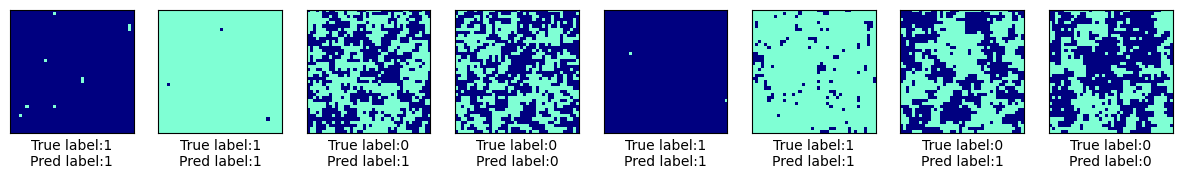

In [26]:
fig6, axarr = plt.subplots(nrows=1, ncols=8, figsize=(15,5))
for i in range(8):
    axarr[i].imshow(seldata[i].reshape(40,40), cmap = cmap) 
    axarr[i].set_xlabel('True label:'+str(sellabels[i])+'\n'+'Pred label:'+str(ypred[i]))
    axarr[i].set_yticks([])
    axarr[i].set_xticks([])

Unfortunately, there are two instances that are misclassified by our Logistic Regressor classifier. At least visually, this is understandable.

However, a look at the corresponding probabilities reveals some concerns:

In [27]:
ypred_prob[:8]

array([[0.35123293, 0.64876707],
       [0.3290957 , 0.6709043 ],
       [0.04824153, 0.95175847],
       [0.80528505, 0.19471495],
       [0.34499806, 0.65500194],
       [0.18535834, 0.81464166],
       [0.38049794, 0.61950206],
       [0.95773133, 0.04226867]])

sample 0: Ordered  (decent confidence)  
sample 1: Ordered  (decent confidence)  
sample 2 is predicted to be Ordered WITH HIGH CONFIDENCE... BUT INCORRECTLY!  
.....

Something is going wrong here, because the confidence level of very uncertain cases appears to be too high. 

The conclusion is that the main indicator for this model is lack of consistency between spin alignments, which is not modeled well by our regressor. It's a tricky problem because many algorithms tend to look at the value of each feature to decide - for many of them, it's hard to represent the correlation among features as an indicator. 

### Question: 

Which algorithm from the ones we have seen so far would you recommend using instead of Logistic Regression?